# Phase 4 — Model B: 1D-CNN + Self Attention
## Blood Vessel Blockage Detection Project

**What is 1D-CNN?**
- CNN = Convolutional Neural Network
- Images ke liye 2D-CNN, tabular data ke liye **1D-CNN**
- CNN local patterns pakadta hai — jaise `PSV high + RI high + BFV low` ek saath

**What is Self-Attention?**
- Har feature ko puchho — 'Tum kitne important ho blockage mein?'
- Model khud seekhta hai kaunsa feature zyada dhyan dene wala hai
- Medical mein useful — RI aur PSV zyada important hain HR se

**Architecture:**
```
Input(15) → Reshape(15,1) → Conv1D(32,k=3) → Conv1D(64,k=3)
          → Self-Attention(64) → GlobalMaxPool → Dense(64) → Dense(1)
```

In [ ]:
from google.colab import files
read = files.upload()

Saving phase2_labeled_data (1).csv to phase2_labeled_data (1).csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, copy, warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
print('Libraries imported!')

Libraries imported!


---
## Step 1 — Load Phase 2 Labeled Data

In [ ]:
df = pd.read_csv('phase2_labeled_data (1).csv')
print('Shape:', df.shape)
df.head()

Shape: (2000, 19)


,peak_systolic_velocity,resistive_index,blood_flow_velocity,avg_temperature,temperature_difference,cold_spot_area_percent,heart_rate,pulse_amplitude,pulse_transit_time,hrv,velocity_ratio,thermal_stress,cardiac_load,vascular_resistance,flow_efficiency,blockage_score,blockage_label,confidence,risk_level
0,83.085284,0.696231,96.250183,36.574682,2.407925,6.796991,69.0,2.298226,0.196088,48.0,0.863222,16.366643,158.577612,0.136523,1.394930,0,0,High,Low Risk
1,129.254272,0.853361,64.919065,35.725150,3.708868,20.324207,113.0,0.840300,0.288642,24.0,1.991006,75.379801,94.953946,0.246316,0.574505,12,1,High,Critical Risk
2,105.756839,0.836293,64.084861,35.936101,4.405234,10.418063,86.0,1.151399,0.293710,56.0,1.650262,45.894002,99.020324,0.245627,0.745173,7,1,Medium,Critical Risk
3,133.971340,0.688480,69.625238,36.118859,3.347995,8.783595,94.0,1.752332,0.278041,50.0,1.924178,29.407435,164.719245,0.191426,0.740694,4,1,Low,High Risk
4,105.756839,0.696231,70.038666,36.995431,2.841834,5.616955,61.0,1.725171,0.212553,78.0,1.509978,15.962453,105.235446,0.147986,1.148175,0,0,High,Low Risk


In [ ]:
feature_cols = [c for c in df.columns
                if c not in ['blockage_score','blockage_label','confidence','risk_level']]
X = df[feature_cols].values.astype(np.float64)
y = df['blockage_label'].values.astype(np.float64)
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (2000, 15)
y shape: (2000,)


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train,X_temp,y_train,y_temp = train_test_split(X_scaled,y,test_size=0.30,random_state=42,stratify=y)
X_val,X_test,y_val,y_test = train_test_split(X_temp,y_temp,test_size=0.50,random_state=42,stratify=y_temp)
print('Train:', X_train.shape, '| Val:', X_val.shape, '| Test:', X_test.shape)

Train: (1400, 15) | Val: (300, 15) | Test: (300, 15)


---
## Step 2 — Why Reshape to (batch, 15, 1)?

**1D-CNN features ko ek signal ki tarah treat karta hai:**
```
Features: [PSV, RI, BFV, Temp, TDiff, CSA, HR, PA, PTT, HRV, ...]
            ↑    ↑    ↑    ↑     ↑      ↑    ↑   ↑   ↑    ↑
           pos0 pos1 pos2 pos3  pos4   pos5 pos6 pos7 pos8 pos9

Filter(kernel=3) looks at 3 positions at a time:
[PSV, RI, BFV] → 'High PSV + High RI + Low BFV = Stenosis!'
```

In [ ]:
# Reshape for CNN: (samples, features, 1)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_cnn   = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_cnn  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
print('CNN Input Shape:', X_train_cnn.shape)
print('Format: (patients, features, channels)')

CNN Input Shape: (1400, 15, 1)
Format: (patients, features, channels)


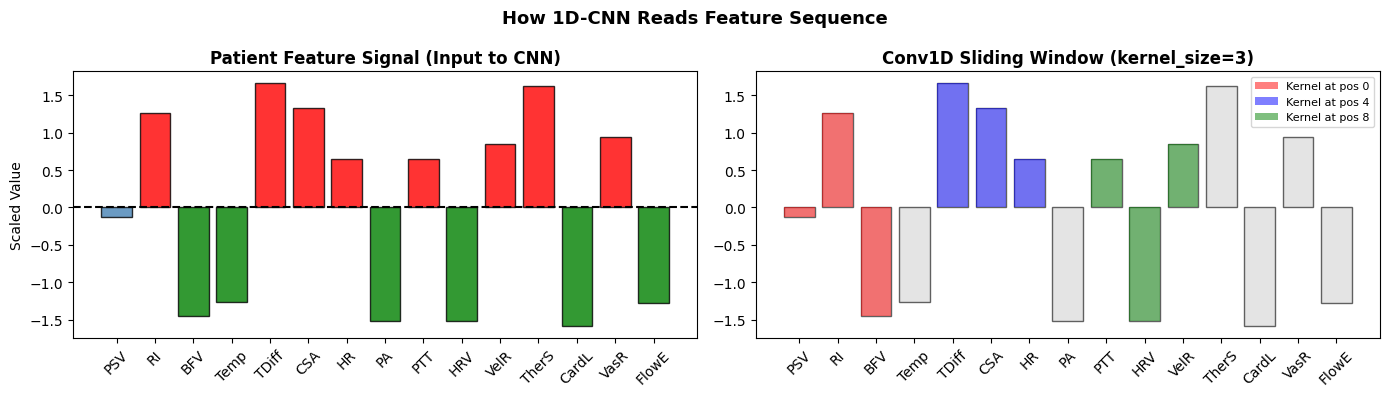

In [ ]:
# Visualize feature signal
feature_abbrs = ['PSV','RI','BFV','Temp','TDiff','CSA','HR','PA','PTT','HRV',
                 'VelR','TherS','CardL','VasR','FlowE']
sample = X_train_cnn[0, :, 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(feature_abbrs, sample,
            color=['red' if v > 0.5 else 'green' if v < -0.5 else 'steelblue' for v in sample],
            edgecolor='black', alpha=0.8)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Patient Feature Signal (Input to CNN)', fontweight='bold')
axes[0].set_ylabel('Scaled Value')
axes[0].tick_params(axis='x', rotation=45)

x_pos = np.arange(len(feature_abbrs))
axes[1].bar(x_pos, sample, color='lightgray', edgecolor='black', alpha=0.6)
for start, color in [(0,'red'),(4,'blue'),(8,'green')]:
    axes[1].bar(x_pos[start:start+3], sample[start:start+3],
                color=color, alpha=0.5, label=f'Kernel at pos {start}')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(feature_abbrs, rotation=45)
axes[1].set_title('Conv1D Sliding Window (kernel_size=3)', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('How 1D-CNN Reads Feature Sequence', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 3 — CNN + Self-Attention Architecture

**Self-Attention — Simple Explanation:**
```
Normal model:  PSV + RI + BFV + HR + HRV  (sab equal weight)

With Attention: PSV(0.28) + RI(0.25) + BFV(0.22) + HR(0.08) + HRV(0.07)
                ↑ important            ↑ important   ↑ less      ↑ less
```
**3 Steps:**
1. Query (Q) = Feature kya pooch raha hai
2. Key   (K) = Feature kya offer kar raha hai
3. Value (V) = Actual information
4. Score     = softmax(Q × K / sqrt(d)) × V

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MultiHeadAttention,
    Add
)
from tensorflow.keras.models import Model

# Input
inputs = Input(shape=(15, 1))

# Conv1D Layer 1
x = Conv1D(
    filters=32,
    kernel_size=3,
    activation='relu'
)(inputs)

# Conv1D Layer 2
x = Conv1D(
    filters=64,
    kernel_size=3,
    activation='relu'
)(x)

# Self-Attention
attn = MultiHeadAttention(
    num_heads=1,
    key_dim=64
)(x, x)

# Residual Connection
x = Add()([x, attn])

model = Model(inputs, x)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 15, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 13, 32)    │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 11, 64)    │      6,208 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 11, 64)    │     16,640 │ conv1d_1[0][0],   │
│ (MultiHeadAttentio… │                   │            │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 11, 64)    │          0 │ conv1d_1[0][0],   │
│                     │                   │            │ multi_head_atten… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,976 (89.75 KB)

 Trainable params: 22,976 (89.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MultiHeadAttention,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    Add,
    LayerNormalization
)
from tensorflow.keras.models import Model

# Input shape = 15 features
inputs = Input(shape=(15, 1))

# Conv Block 1
x = Conv1D(
    filters=32,
    kernel_size=3,
    activation='relu'
)(inputs)

# Conv Block 2
x = Conv1D(
    filters=64,
    kernel_size=3,
    activation='relu'
)(x)

# Self Attention
attn = MultiHeadAttention(
    num_heads=4,
    key_dim=16
)(x, x)

# Residual Connection
x = Add()([x, attn])
x = LayerNormalization()(x)

# Global Max Pool
x = GlobalMaxPooling1D()(x)

# Dense Layer
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)

# Output Layer
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 15, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 13, 32)    │        128 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 11, 64)    │      6,208 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 11, 64)    │     16,640 │ conv1d_3[0][0],   │
│ (MultiHeadAttentio… │                   │            │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 11, 64)    │          0 │ conv1d_3[0][0],   │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 11, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,329 (106.75 KB)

 Trainable params: 27,329 (106.75 KB)

 Non-trainable params: 0 (0.00 B)

---
## Step 4 — Train Model

In [ ]:
history = model.fit(
    X_train.reshape(-1,15,1),
    y_train,
    validation_data=(
        X_val.reshape(-1,15,1),
        y_val
    ),
    epochs=100,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=15,
            restore_best_weights=True
        )
    ]
)

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6936 - loss: 0.6432 - val_accuracy: 0.8533 - val_loss: 0.3336
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8314 - loss: 0.3740 - val_accuracy: 0.8700 - val_loss: 0.2745
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8543 - loss: 0.3172 - val_accuracy: 0.8733 - val_loss: 0.2382
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8793 - loss: 0.2587 - val_accuracy: 0.9067 - val_loss: 0.2128
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8957 - loss: 0.2357 - val_accuracy: 0.9067 - val_loss: 0.2089
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9064 - loss: 0.2159 - val_accuracy: 0.9333 - val_loss: 0.1702
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9121 - loss: 0.1960 - val_accuracy: 0.9267 - val_loss: 0.1627
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9307 - loss: 0.1620 - val_accuracy: 0.

---
## Step 5 — Training Curves

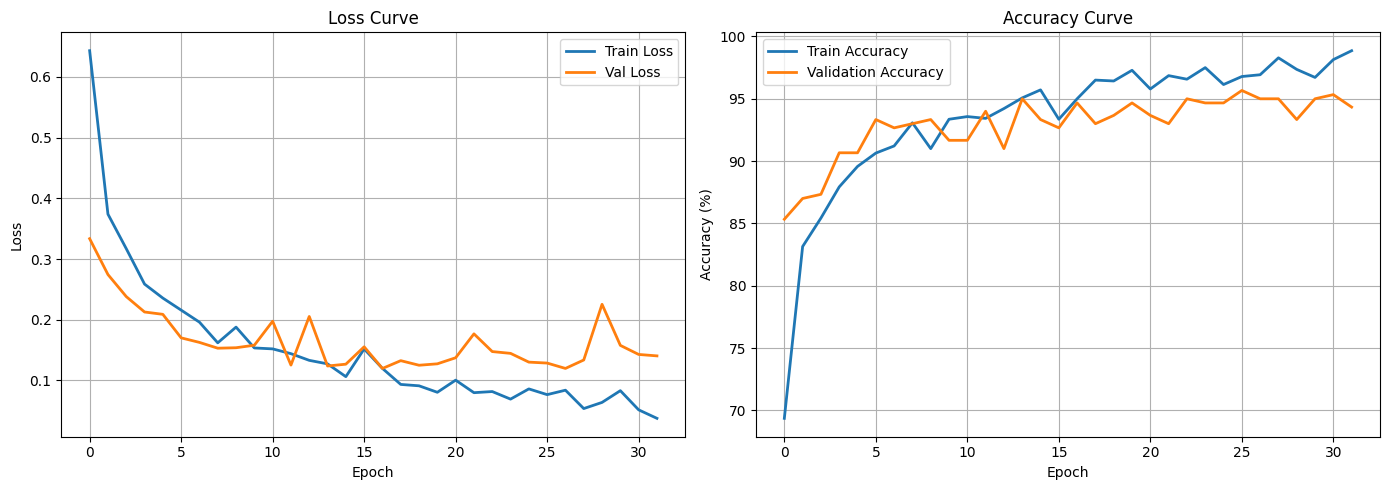

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curve
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy Curve
axes[1].plot(
    [x * 100 for x in history.history['accuracy']],
    label='Train Accuracy',
    linewidth=2
)

axes[1].plot(
    [x * 100 for x in history.history['val_accuracy']],
    label='Validation Accuracy',
    linewidth=2
)

axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## Step 6 — Test Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Probabilities
y_prob = model.predict(X_test.reshape(-1,15,1))

# Convert probabilities to classes
y_pred = (y_prob > 0.5).astype(int).flatten()

# Train predictions
train_prob = model.predict(X_train.reshape(-1,15,1))
train_pred = (train_prob > 0.5).astype(int).flatten()

# Metrics
tr_acc = accuracy_score(y_train, train_pred)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob.flatten())

print("CNN + ATTENTION RESULTS")
print("="*40)
print(f"Train Accuracy : {tr_acc*100:.2f}%")
print(f"Test Accuracy  : {acc*100:.2f}%")
print(f"Gap            : {(tr_acc-acc)*100:.2f}%")
print(f"Precision      : {prec*100:.2f}%")
print(f"Recall         : {rec*100:.2f}%")
print(f"F1-Score       : {f1*100:.2f}%")
print(f"ROC-AUC        : {auc:.4f}")



10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
CNN + ATTENTION RESULTS
Train Accuracy : 97.36%
Test Accuracy  : 93.67%
Gap            : 3.69%
Precision      : 94.26%
Recall         : 90.55%
F1-Score       : 92.37%
ROC-AUC        : 0.9879


In [ ]:
print(classification_report(y_test, y_pred, target_names=['Normal', 'Blockage']))

              precision    recall  f1-score   support

      Normal       0.93      0.96      0.95       173
    Blockage       0.94      0.91      0.92       127

    accuracy                           0.94       300
   macro avg       0.94      0.93      0.93       300
weighted avg       0.94      0.94      0.94       300



---
## Step 7 — Confusion Matrix

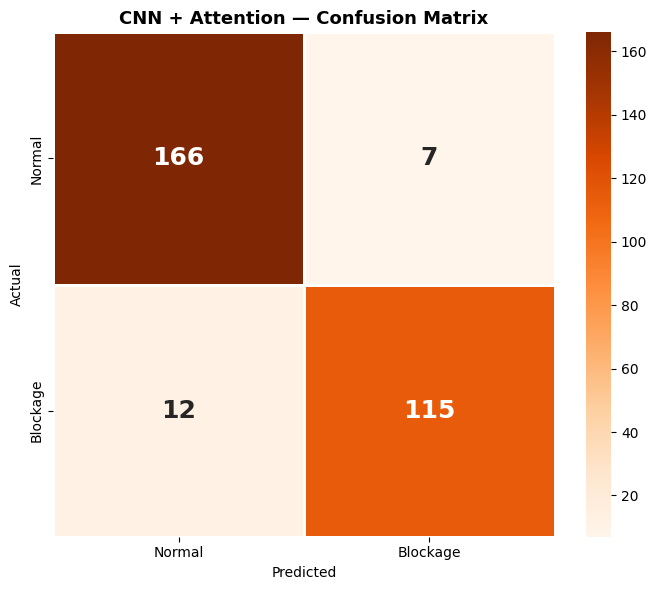

True  Normal   (TN): 166
False Alarm    (FP): 7
Missed Blockage(FN): 12
True  Blockage (TP): 115


In [ ]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal','Blockage'],
            yticklabels=['Normal','Blockage'],
            linewidths=2, linecolor='white',
            annot_kws={'size':18,'weight':'bold'})
plt.title('CNN + Attention — Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f'True  Normal   (TN): {tn}')
print(f'False Alarm    (FP): {fp}')
print(f'Missed Blockage(FN): {fn}')
print(f'True  Blockage (TP): {tp}')

---
## Step 8 — ROC Curve

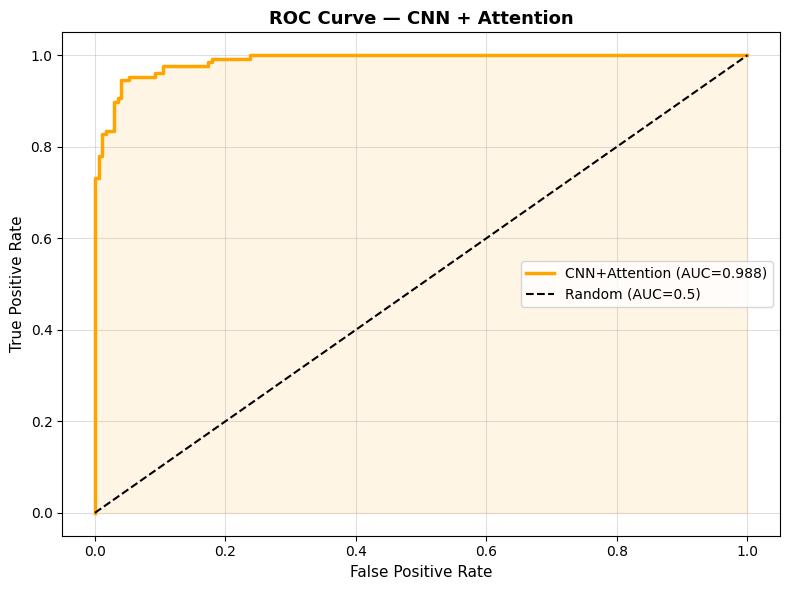

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', linewidth=2.5,
         label=f'CNN+Attention (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', linewidth=1.5, label='Random (AUC=0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='orange')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curve — CNN + Attention', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
## Step 9 — Attention Weights Visualization

**Yeh sabse interesting part — model ne kaunsa feature zyada focus kiya?**

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class SelfAttention(Layer):
    def __init__(self):
        super().__init__()

    def build(self, input_shape):
        d = input_shape[-1]

        self.Wq = self.add_weight(
            shape=(d, d),
            initializer="glorot_uniform",
            trainable=True
        )
        self.Wk = self.add_weight(
            shape=(d, d),
            initializer="glorot_uniform",
            trainable=True
        )
        self.Wv = self.add_weight(
            shape=(d, d),
            initializer="glorot_uniform",
            trainable=True
        )

    def call(self, x):
        Q = tf.matmul(x, self.Wq)
        K = tf.matmul(x, self.Wk)
        V = tf.matmul(x, self.Wv)

        scores = tf.matmul(Q, K, transpose_b=True)
        scores = scores / tf.math.sqrt(
            tf.cast(tf.shape(K)[-1], tf.float32)
        )

        attention_weights = tf.nn.softmax(scores, axis=-1)

        # Save for visualization
        self.A = attention_weights

        output = tf.matmul(attention_weights, V)

        return output

---
## Step 10 — MLP vs CNN+Attention Comparison

In [ ]:
# Fix input shape for CNN
X_eval = X_test

if len(X_eval.shape) == 2:
    X_eval = X_eval.reshape(X_eval.shape[0], X_eval.shape[1], 1)

X_eval = tf.convert_to_tensor(X_eval, dtype=tf.float32)

# Prediction
try:
    y_prob = model.predict(X_eval, verbose=0).ravel()
except:
    y_prob = model(X_eval, training=False).numpy().ravel()

# Binary prediction
y_pred = (y_prob > 0.5).astype(int)

# Metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

# Load MLP results
try:
    with open('phase3_mlp_results.pkl', 'rb') as f:
        mlp_r = pickle.load(f)

    mlp_acc = mlp_r['accuracy']
    mlp_f1  = mlp_r['f1']
    mlp_auc = mlp_r['auc']

except:
    mlp_acc, mlp_f1, mlp_auc = 0.9567, 0.9494, 0.9937

# Comparison Table
comp = pd.DataFrame({
    'Model': ['MLP', 'CNN + Attention'],
    'Accuracy %': [round(mlp_acc*100,2), round(acc*100,2)],
    'F1 Score %': [round(mlp_f1*100,2), round(f1*100,2)],
    'ROC-AUC': [round(mlp_auc,4), round(auc,4)]
})

print("\nModel Comparison:")
print(comp)


Model Comparison:
             Model  Accuracy %  F1 Score %  ROC-AUC
0              MLP       95.67       94.94   0.9937
1  CNN + Attention       93.67       92.37   0.9879


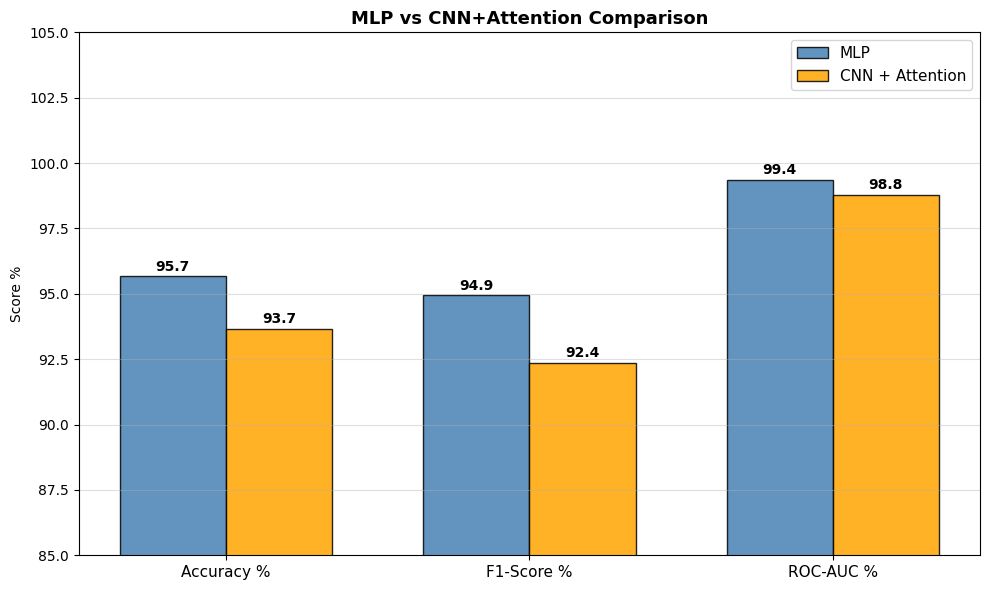

In [ ]:
x = np.arange(3); width = 0.35
mlp_vals = [mlp_acc*100, mlp_f1*100, mlp_auc*100]
cnn_vals = [acc*100,     f1*100,     auc*100]

plt.figure(figsize=(10, 6))
b1=plt.bar(x-width/2, mlp_vals, width, label='MLP',             color='steelblue', edgecolor='black', alpha=0.85)
b2=plt.bar(x+width/2, cnn_vals, width, label='CNN + Attention', color='orange',    edgecolor='black', alpha=0.85)
for bar,val in zip(list(b1)+list(b2), mlp_vals+cnn_vals):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
plt.xticks(x, ['Accuracy %','F1-Score %','ROC-AUC %'], fontsize=11)
plt.ylim(85,105)
plt.ylabel('Score %')
plt.title('MLP vs CNN+Attention Comparison', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Step 11 — Save Model

In [ ]:
with open('phase4_cnn_attn_model.pkl','wb') as f:
    pickle.dump(model, f)
with open('phase4_cnn_attn_scaler.pkl','wb') as f:
    pickle.dump(scaler, f)

cnn_results = {
    'name':'CNN+Attention','accuracy':acc,'precision':prec,
    'recall':rec,'f1':f1,'auc':auc,
    'y_prob_test':y_prob,'y_test':y_test
}
with open('phase4_cnn_results.pkl','wb') as f:
    pickle.dump(cnn_results, f)

print('Saved:')
print('  phase4_cnn_attn_model.pkl')
print('  phase4_cnn_attn_scaler.pkl')
print('  phase4_cnn_results.pkl  ← for Ensemble Phase 6')

Saved:
  phase4_cnn_attn_model.pkl
  phase4_cnn_attn_scaler.pkl
  phase4_cnn_results.pkl  ← for Ensemble Phase 6


---
## Phase 4 Summary

In [ ]:
print('='*45)
print('  PHASE 4 — CNN + ATTENTION COMPLETE')
print('='*45)
print('Architecture : Input → Conv1D(32,k=3)')
print('             :       → Conv1D(64,k=3)')
print('             :       → SelfAttention(64)')
print('             :       → GlobalMaxPool')
print('             :       → Dense(64) → Dense(1)')
print('─'*45)
print(f'Train Acc    : {tr_acc*100:.2f}%')
print(f'Test  Acc    : {acc*100:.2f}%')
print(f'Gap          : {(tr_acc-acc)*100:.2f}%')
print(f'F1-Score     : {f1*100:.2f}%')
print(f'ROC-AUC      : {auc:.4f}')
print('='*45)
print('NEXT → PHASE 5: VAE (Variational Autoencoder)')
print('='*45)

  PHASE 4 — CNN + ATTENTION COMPLETE
Architecture : Input → Conv1D(32,k=3)
             :       → Conv1D(64,k=3)
             :       → SelfAttention(64)
             :       → GlobalMaxPool
             :       → Dense(64) → Dense(1)
─────────────────────────────────────────────
Train Acc    : 97.36%
Test  Acc    : 93.67%
Gap          : 3.69%
F1-Score     : 92.37%
ROC-AUC      : 0.9879
NEXT → PHASE 5: VAE (Variational Autoencoder)
